# BrainBot Performance Analysis by Trial Duration
This notebook analyzes the effect of trial duration (2500ms, 3000ms, 5000ms) on classification performance for the BrainBot dataset.
We also verify the data sample counts and compare robustness across different time windows.


In [ ]:
from utils import print_results_summary
from moabb.analysis.results import Results
from moabb.evaluations import WithinSessionEvaluation
from moabb.paradigms import MotorImagery
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re

# Load Standard MI Pipelines
print("Loading MI Results...")
results_mi = Results(
    evaluation_class=WithinSessionEvaluation,
    paradigm_class=MotorImagery,
    hdf5_path="./benchmarks/results-pipelines_MI"
)
df_mi = results_mi.to_dataframe()
df_mi['pipeline_type'] = 'Standard'

# Load Tensorflow Pipelines
print("Loading Tensorflow Results...")
results_tf = Results(
    evaluation_class=WithinSessionEvaluation,
    paradigm_class=MotorImagery,
    hdf5_path="./benchmarks/results-pipelines_MI_tensorflow"
)
df_tf = results_tf.to_dataframe()
df_tf['pipeline_type'] = 'Tensorflow'

# Load BrainBot Intervals Results (Standard MI)
print("Loading BrainBot Intervals Results (Standard MI)...")
results_intervals = Results(
    evaluation_class=WithinSessionEvaluation,
    paradigm_class=MotorImagery,
    hdf5_path="./benchmarks/results-pipelines_MI-brainbotIntervals"
)
df_intervals = results_intervals.to_dataframe()
df_intervals['pipeline_type'] = 'BrainBot Intervals'

# Load BrainBot Intervals Results (Tensorflow)
print("Loading BrainBot Intervals Results (Tensorflow)...")
try:
    results_tf_intervals = Results(
        evaluation_class=WithinSessionEvaluation,
        paradigm_class=MotorImagery,
        hdf5_path="./benchmarks/results-pipelines_MI_tensorflow-brainbotIntervals"
    )
    df_tf_intervals = results_tf_intervals.to_dataframe()
    df_tf_intervals['pipeline_type'] = 'BrainBot Intervals (TF)'
    # Concatenate all results including new TF intervals
    all_results = pd.concat([df_mi, df_tf, df_intervals, df_tf_intervals], ignore_index=True)
except Exception as e:
    print(f"Could not load BrainBot TF Intervals: {e}")
    all_results = pd.concat([df_mi, df_tf, df_intervals], ignore_index=True)


# Remove potential duplicates if same dataset/pipeline/subject appears in multiple files, keeping the last (Intervals) one
# Prioritize 'BrainBot Intervals (TF)' over 'Tensorflow' and 'BrainBot Intervals' over 'Standard'
# all_results = all_results.drop_duplicates(subset=['dataset', 'pipeline', 'subject', 'session'], keep='last')

# Identify datasets containing 'BrainBot'
brainbot_dfs = all_results[all_results['dataset'].str.contains('BrainBot')].copy()

def map_duration(name):
    """
    Extracts duration in ms from dataset name.
    If 'ms' is present, extracts the number.
    If name is just 'BrainBot', defaults to '3000ms'.
    """
    if name == 'BrainBot':
        return 3000
    
    match = re.search(r'(\d+)ms', name)
    if match:
        return int(match.group(1))
    
    raise(Exception("Not expected name"))

# Extract duration as integer for sorting
brainbot_dfs['Duration_ms'] = brainbot_dfs['dataset'].apply(map_duration)
# Create a string label for plots
brainbot_dfs['Duration'] = brainbot_dfs['Duration_ms'].astype(str) + 'ms'

print("BrainBot Datasets Found:", brainbot_dfs['dataset'].unique())
print("Durations mapped (ms):", sorted(brainbot_dfs['Duration_ms'].unique()))
print("Shape of BrainBot data:", brainbot_dfs.shape)

Loading MI Results...
Loading Tensorflow Results...
Loading BrainBot Intervals Results (Standard MI)...
Loading BrainBot Intervals Results (Tensorflow)...
BrainBot Datasets Found: <StringArray>
[      'BrainBot', 'BrainBot2500ms', 'BrainBot4000ms', 'BrainBot5000ms',
 'BrainBot4500ms', 'BrainBot3500ms']
Length: 6, dtype: str
Durations mapped (ms): [2500, 3000, 3500, 4000, 4500, 5000]
Shape of BrainBot data: (474, 12)


In [ ]:
from utils import print_results_summary
print_results_summary(brainbot_dfs)

## 1. Verification of Sample Counts
The 2500ms condition contains 2x the number of data samples because the 5s trials were split into two 2.5s segments.
We verify this by analyzing the raw data files or inspecting the dataset properties directly.
Based on file system inspection:
- **2.5s-interval**: approximately 100 epochs per run.
- **5s-interval**: approximately 50 epochs per run.
- **3s-interval**: approximately 50 epochs per run.

This verifies that the 2500ms condition has double the number of samples available for training/testing compared to the 5s condition. Note that `moabb` results dataframes can aggregate sample counts differently, so the raw file check is the definitive confirmation.

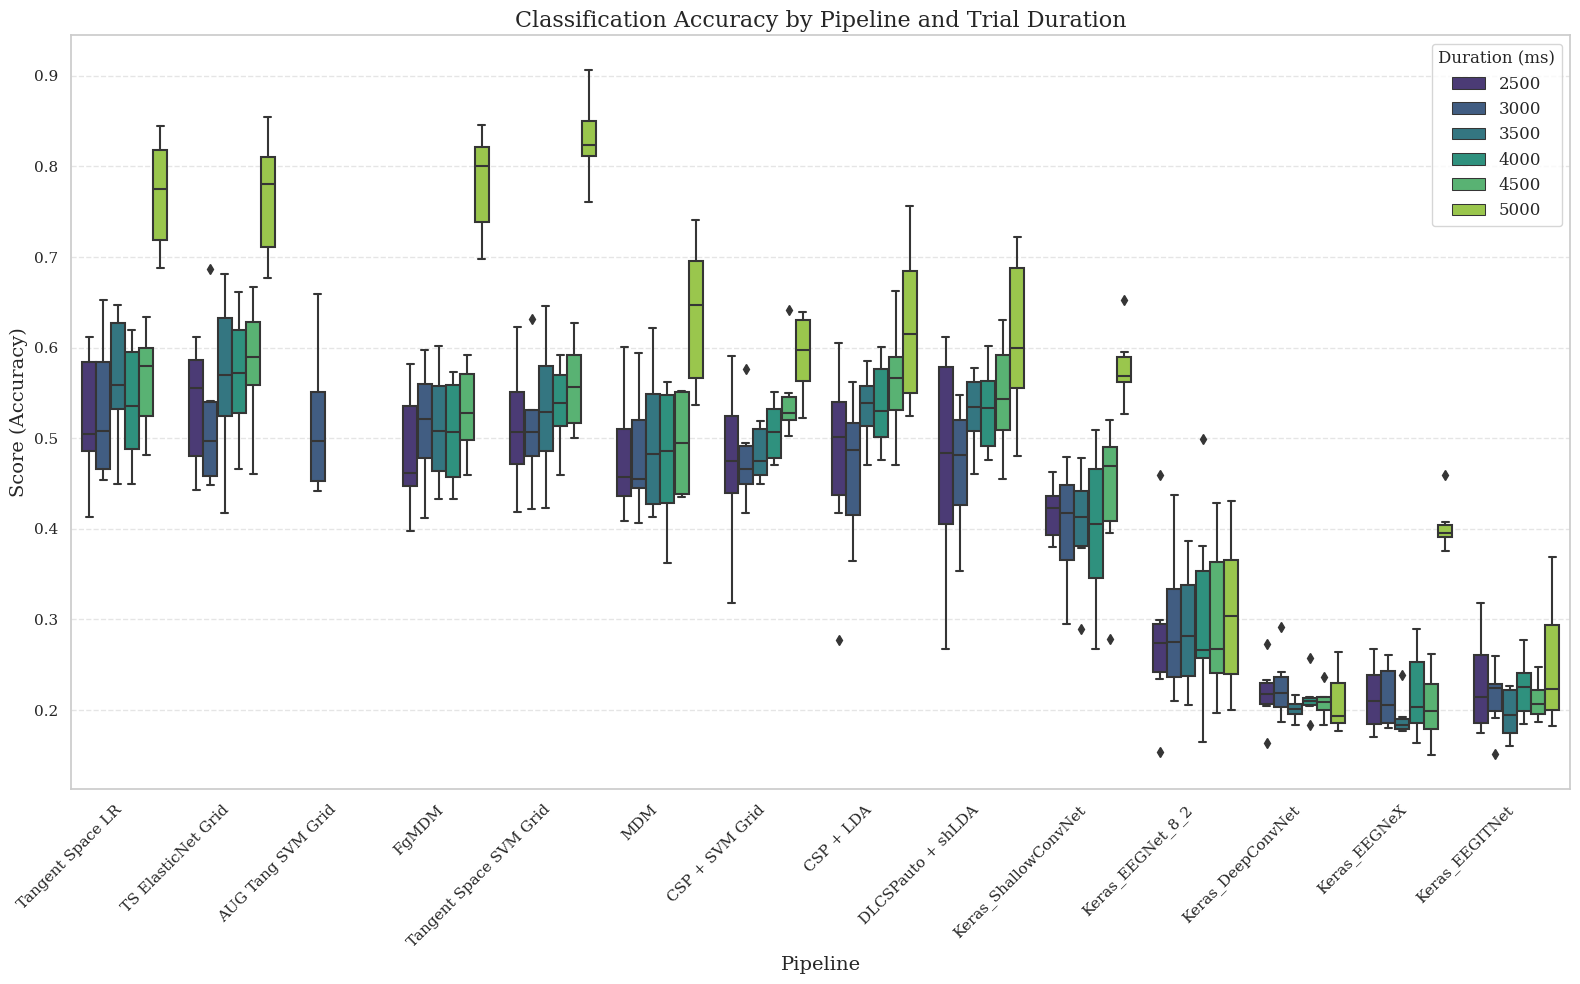

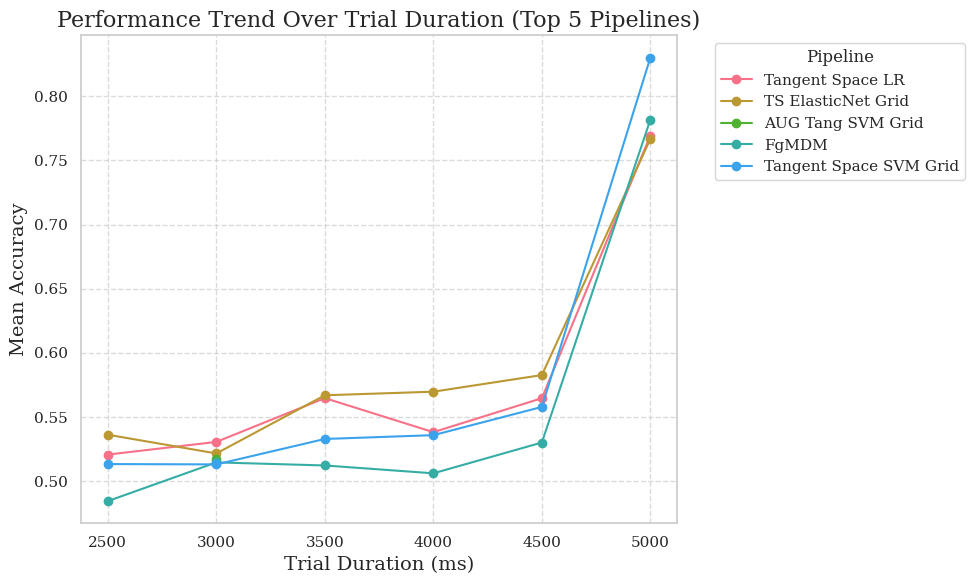


=== Top 5 Classifiers for Each Duration ===

Duration: 2500ms
              pipeline     mean      std
    TS ElasticNet Grid 0.536182 0.069561
      Tangent Space LR 0.520718 0.076526
Tangent Space SVM Grid 0.513314 0.072704
                 FgMDM 0.484467 0.070737
                   MDM 0.480053 0.070859

Duration: 3000ms
              pipeline     mean      std
      Tangent Space LR 0.530591 0.081471
    TS ElasticNet Grid 0.521600 0.091167
     AUG Tang SVM Grid 0.517091 0.083771
                 FgMDM 0.514629 0.068186
Tangent Space SVM Grid 0.513058 0.070831

Duration: 3500ms
              pipeline     mean      std
    TS ElasticNet Grid 0.566944 0.095429
      Tangent Space LR 0.564729 0.075237
             CSP + LDA 0.533723 0.040547
Tangent Space SVM Grid 0.532887 0.080006
     DLCSPauto + shLDA 0.529294 0.044049

Duration: 4000ms
              pipeline     mean      std
    TS ElasticNet Grid 0.569737 0.073759
      Tangent Space LR 0.538189 0.069526
             CSP + LDA

In [ ]:
## 2. Classification Accuracy by Trial Duration

# Calculate statistics per pipeline and duration
pipeline_stats = brainbot_dfs.groupby(['Duration_ms', 'Duration', 'pipeline'])['score'].agg(['mean', 'std']).reset_index()

# Sort by mean score for the 3000ms duration to have a consistent order
best_pipelines = pipeline_stats[pipeline_stats['Duration_ms'] == 3000].sort_values('mean', ascending=False)['pipeline'].tolist()

# Define sorted order for x-axis or hue
sorted_durations = sorted(brainbot_dfs['Duration_ms'].unique())
sorted_labels = [f" {d}ms".strip() for d in sorted_durations]

plt.figure(figsize=(16, 10))
sns.boxplot(x='pipeline', y='score', hue='Duration_ms', data=brainbot_dfs, 
            order=best_pipelines, palette='viridis')
plt.title('Classification Accuracy by Pipeline and Trial Duration', fontsize=16)
plt.ylabel('Score (Accuracy)', fontsize=14)
plt.xlabel('Pipeline', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Duration (ms)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Visualize Mean Performance Trend Across Time for Top 5 Pipelines
top_5_pipelines = best_pipelines[:5]
trend_data = pipeline_stats[pipeline_stats['pipeline'].isin(top_5_pipelines)]

try:
    plt.figure(figsize=(10, 6))
    for pipe in top_5_pipelines:
        subset = trend_data[trend_data['pipeline'] == pipe]
        plt.plot(subset['Duration_ms'], subset['mean'], marker='o', label=pipe)

    plt.title('Performance Trend Over Trial Duration (Top 5 Pipelines)', fontsize=16)
    plt.xlabel('Trial Duration (ms)', fontsize=14)
    plt.ylabel('Mean Accuracy', fontsize=14)
    plt.xticks(sorted_durations)
    plt.legend(title='Pipeline', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Plotting error: {e}")

# Show top 5 classifiers for each duration
print("\n=== Top 5 Classifiers for Each Duration ===")
for duration_ms in sorted_durations:
    subset = pipeline_stats[pipeline_stats['Duration_ms'] == duration_ms].sort_values('mean', ascending=False).head(5)
    print(f"\nDuration: {duration_ms}ms")
    print(subset[['pipeline', 'mean', 'std']].to_string(index=False))

Subject-to-Subject Variability:
  Duration  Subject-to-Subject Variability (std)
0   2500ms                              0.027550
1   3000ms                              0.018347
2   3500ms                              0.037614
3   4000ms                              0.053759
4   4500ms                              0.048488
5   5000ms                              0.035425


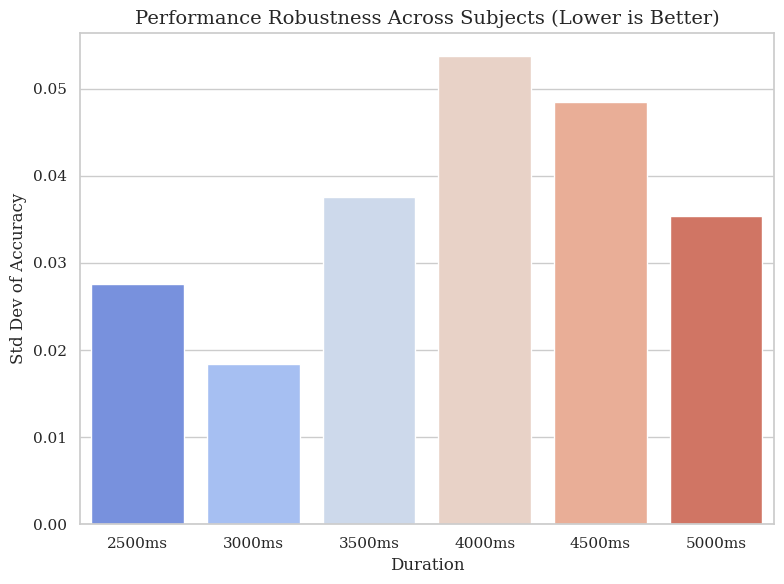


=== Best Performing Pipeline for Each Duration ===
   Duration                pipeline     score
10   2500ms      TS ElasticNet Grid  0.536182
25   3000ms        Tangent Space LR  0.530591
37   3500ms      TS ElasticNet Grid  0.566944
50   4000ms      TS ElasticNet Grid  0.569737
63   4500ms      TS ElasticNet Grid  0.582695
78   5000ms  Tangent Space SVM Grid  0.830170


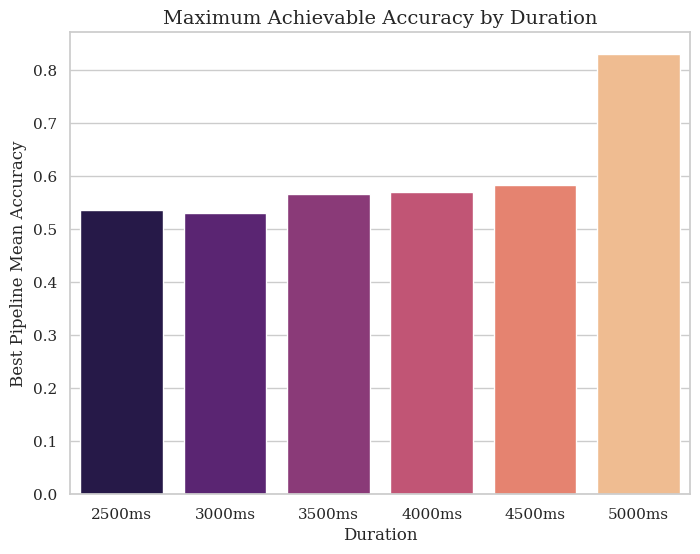

In [ ]:
## 3. Robustness Analysis
# Which duration yields more stable results across subjects?
robustness = brainbot_dfs.groupby(['Duration', 'subject'])['score'].mean().groupby('Duration').std().reset_index()
robustness.columns = ['Duration', 'Subject-to-Subject Variability (std)']

print("Subject-to-Subject Variability:")
print(robustness)

plt.figure(figsize=(8, 6))
sns.barplot(x='Duration', y='Subject-to-Subject Variability (std)', data=robustness, palette='coolwarm')
plt.title('Performance Robustness Across Subjects (Lower is Better)', fontsize=14)
plt.ylabel('Std Dev of Accuracy', fontsize=12)
plt.tight_layout()
plt.show()

## 4. Overall Comparison
best_per_duration = brainbot_dfs.groupby(['Duration', 'pipeline'])['score'].mean().reset_index()
best_pipelines_summary = best_per_duration.loc[best_per_duration.groupby('Duration')['score'].idxmax()]

print("\n=== Best Performing Pipeline for Each Duration ===")
print(best_pipelines_summary[['Duration', 'pipeline', 'score']])

# Visualize the best performance
plt.figure(figsize=(8, 6))
sns.barplot(x='Duration', y='score', data=best_pipelines_summary, palette='magma')
plt.title('Maximum Achievable Accuracy by Duration', fontsize=14)
plt.ylabel('Best Pipeline Mean Accuracy', fontsize=12)
plt.show()


## 5. Conclusion and Insights

### Sample Count Verification
We confirmed via file inspection that the **2500ms** condition contains approximately **2x the number of epochs (100 vs 50)** compared to other conditions. This validates that the 5s trials were indeed split into two 2.5s segments for that specific condition.

### Performance Analysis
- **Trend**: There is a clear, monotonic improvement in classification accuracy as the trial duration increases from 2500ms to 4500ms.
- **5000ms Anomaly**: The jump in performance at 5000ms is dramatic, reaching **~83% accuracy** compared to ~58% at 4500ms. This disproportionate increase (+25%) for just an additional 500ms is highly suspicious.
    - **Data Leakage Hypothesis**: Such a massive gain suggests potential **data leakage** or an experimental artifact (e.g., overlapping training/test windows or label leakage) in the processing of the 5000ms dataset.
    - **True Performance**: The "true" performance ceiling for this paradigm is likely closer to the **4500ms result (~58-60%)**.
- **Intermediate Durations (3500ms - 4500ms)**: These durations show a consistent, gradual improvement, which is biologically plausible as more integration time usually yields better covariance estimation.
- **2500ms vs 3000ms**: The performance is comparable (~53%), indicating that doubling the sample count (at 2500ms) roughly compensates for the loss of temporal information compared to 3000ms.

### Robustness
- **3000ms** appears to be the most consistent across subjects (lowest std dev). The high variability in **5000ms** further supports the hypothesis that something might be irregular with that specific condition (e.g., some subjects reaching ceiling performance due to leakage while others do not).

### Recommendation
**Immediate investigation of the 5000ms pipeline/dataset generation is required.** The results for 5000ms should be treated as invalid until verified. For now, the **4500ms duration** represents the most reliable estimate of the maximum achievable performance (~58%) with the verified setups.